In [1]:
import pandas as pd
import numpy as np
!pip install scipy
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Frequentist/Proj 1 - Linear Regression/prostate.data.txt', sep='\t')
df = df.rename(columns={df.columns[0]: 'id'})

Mounted at /content/drive


In [2]:
np.set_printoptions(precision=5) # 5 decimal points

features = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]
labels = "lpsa"

print(df.shape)
print(df['train'].value_counts())
df.head()

train = df[df["train"] == "T"].reset_index(drop=True)
test = df[df["train"] == "F"].reset_index(drop=True)

print(f"n_train = {len(train)}, n_test = {len(test)}  (book: 67 / 30). MATCHES! \n")

corr = train[features].corr()
print("Correlation matrix (training set):")
print(corr.round(3))

published_3_1 = {
    ("lweight", "lcavol"): 0.300,
    ("age", "lcavol"): 0.286, ("age", "lweight"): 0.317,
    ("lbph", "lcavol"): 0.063, ("lbph", "lweight"): 0.437, ("lbph", "age"): 0.287,
    ("svi", "lcavol"): 0.593, ("svi", "lweight"): 0.181, ("svi", "age"): 0.129, ("svi", "lbph"): -0.139,
    ("lcp", "lcavol"): 0.692, ("lcp", "lweight"): 0.157, ("lcp", "age"): 0.173,
    ("lcp", "lbph"): -0.089, ("lcp", "svi"): 0.671,
    ("gleason", "lcavol"): 0.426, ("gleason", "lweight"): 0.024, ("gleason", "age"): 0.366,
    ("gleason", "lbph"): 0.033, ("gleason", "svi"): 0.307, ("gleason", "lcp"): 0.476,
    ("pgg45", "lcavol"): 0.483, ("pgg45", "lweight"): 0.074, ("pgg45", "age"): 0.276,
    ("pgg45", "lbph"): -0.030, ("pgg45", "svi"): 0.481, ("pgg45", "lcp"): 0.663, ("pgg45", "gleason"): 0.757,
}

print("\nComparison to published Table 3.1:")
max_abs_diff = 0.0
for (a, b), book_val in published_3_1.items():
    calculated_corr = corr.loc[a, b]
    diff = abs(calculated_corr - book_val)
    print(f"  corr({a:8s},{b:8s}) = {calculated_corr:6.3f}   book = {book_val:6.3f}   diff = {diff:.4f}")
print("Relatively matches (to three decimal points)!")

(97, 11)
train
T    67
F    30
Name: count, dtype: int64
n_train = 67, n_test = 30  (book: 67 / 30). MATCHES! 

Correlation matrix (training set):
         lcavol  lweight    age   lbph    svi    lcp  gleason  pgg45
lcavol    1.000    0.300  0.286  0.063  0.593  0.692    0.426  0.483
lweight   0.300    1.000  0.317  0.437  0.181  0.157    0.024  0.074
age       0.286    0.317  1.000  0.287  0.129  0.173    0.366  0.276
lbph      0.063    0.437  0.287  1.000 -0.139 -0.089    0.033 -0.030
svi       0.593    0.181  0.129 -0.139  1.000  0.671    0.307  0.481
lcp       0.692    0.157  0.173 -0.089  0.671  1.000    0.476  0.663
gleason   0.426    0.024  0.366  0.033  0.307  0.476    1.000  0.757
pgg45     0.483    0.074  0.276 -0.030  0.481  0.663    0.757  1.000

Comparison to published Table 3.1:
  corr(lweight ,lcavol  ) =  0.300   book =  0.300   diff = 0.0002
  corr(age     ,lcavol  ) =  0.286   book =  0.286   diff = 0.0003
  corr(age     ,lweight ) =  0.317   book =  0.317   diff = 0.

In [3]:
X_all_raw = df[features].values.astype(float)
mu = X_all_raw.mean(axis=0)
sigma = X_all_raw.std(axis=0, ddof=1)   # sample sd, matches R's scale()
X_all = (X_all_raw - mu) / sigma

is_train = (df["train"] == "T").values
X_train = X_all[is_train]
X_test  = X_all[~is_train]
y_train = df.loc[is_train, labels].values.astype(float)
y_test  = df.loc[~is_train, labels].values.astype(float)

n, p = X_train.shape
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (67, 8), X_test: (30, 8)


In [4]:
def ols_fit(X, y):
    """Plain OLS via the normal equations, ESL eq. (3.6)."""
    n, p = X.shape
    X1 = np.column_stack([np.ones(n), X])
    XtX = X1.T @ X1
    XtX_inv = np.linalg.inv(XtX)
    beta_hat = XtX_inv @ X1.T @ y                # eq. 3.6
    y_hat = X1 @ beta_hat
    resid = y - y_hat
    rss = resid @ resid
    dof = n - p - 1
    sigma2_hat = rss / dof                       # eq. 3.8
    var_beta = sigma2_hat * XtX_inv              # eq. 3.10
    se_beta = np.sqrt(np.diag(var_beta))
    z_scores = beta_hat / se_beta                # eq. 3.12
    return beta_hat, se_beta, z_scores, sigma2_hat, rss

beta_hat, se_beta, z_scores, sigma2_hat, rss_train = ols_fit(X_train, y_train)

names = ["Intercept"] + features
print(f"{'Term':10s} {'Coefficient':>12s} {'Std. Error':>12s} {'Z Score':>10s}")
for nm, b, se, z in zip(names, beta_hat, se_beta, z_scores):
    print(f"{nm:10s} {b:12.3f} {se:12.3f} {z:10.2f}")

published_3_2 = {
    "Intercept": (2.465, 0.089, 27.6),
    "lcavol":    (0.680, 0.127, 5.37),
    "lweight":   (0.263, 0.096, 2.75),
    "age":       (-0.141, 0.101, -1.40),
    "lbph":      (0.210, 0.102, 2.06),
    "svi":       (0.305, 0.124, 2.47),
    "lcp":       (-0.288, 0.155, -1.87),
    "gleason":   (-0.021, 0.145, -0.15),
    "pgg45":     (0.267, 0.154, 1.74),
}

print("\nComparison to published Table 3.2:")
for nm, b, se, z in zip(names, beta_hat, se_beta, z_scores):
    bb, bse, bz = published_3_2[nm]
    print(f"{nm:10s} {b:8.3f}/{bb:<8.3f}   {se:7.3f}/{bse:<7.3f}   {z:7.2f}/{bz:<7.2f}")

sigma_hat = np.sqrt(sigma2_hat)
print(f"\nResidual std error: {sigma_hat:.4f}  (book: 0.712)")

# cross-check
X1_train = np.column_stack([np.ones(n), X_train])
beta_lstsq, *_ = np.linalg.lstsq(X1_train, y_train, rcond=None)
print("max |beta_hat - lstsq| =", np.max(np.abs(beta_hat - beta_lstsq)))

X1_test = np.column_stack([np.ones(len(X_test)), X_test])
test_mse_ols = np.mean((y_test - X1_test @ beta_hat) ** 2)
print(f"OLS test-set MSE = {test_mse_ols:.3f}  (book: 0.521)")

Term        Coefficient   Std. Error    Z Score
Intercept         2.465        0.089      27.60
lcavol            0.680        0.127       5.37
lweight           0.263        0.096       2.75
age              -0.141        0.101      -1.40
lbph              0.210        0.102       2.06
svi               0.305        0.124       2.47
lcp              -0.288        0.155      -1.87
gleason          -0.021        0.145      -0.15
pgg45             0.267        0.154       1.74

Comparison to published Table 3.2:
Intercept     2.465/2.465        0.089/0.089       27.60/27.60  
lcavol        0.680/0.680        0.127/0.127        5.37/5.37   
lweight       0.263/0.263        0.096/0.096        2.75/2.75   
age          -0.141/-0.141       0.101/0.101       -1.40/-1.40  
lbph          0.210/0.210        0.102/0.102        2.06/2.06   
svi           0.305/0.305        0.124/0.124        2.47/2.47   
lcp          -0.288/-0.288       0.155/0.155       -1.87/-1.87  
gleason      -0.021/-0.021   

In [5]:
def ridge_fit(X, y, lam):
    """Ridge via ESL eq. (3.44); intercept = mean(y), per ESL 3.4.1."""
    n, p = X.shape
    y_mean = y.mean()
    y_c = y - y_mean
    beta = np.linalg.inv(X.T @ X + lam * np.eye(p)) @ X.T @ y_c
    return y_mean, beta

def effective_df(X, lam):
    """ESL eq. (3.50) via SVD."""
    _, d, _ = np.linalg.svd(X, full_matrices=False)
    return np.sum(d ** 2 / (d ** 2 + lam))

# ridge(lambda=0) should equal OLS slopes
beta0_0, beta_0 = ridge_fit(X_train, y_train, 0.0)
print("ridge(lambda=0) vs OLS slopes, max diff:", np.max(np.abs(beta_0 - beta_hat[1:])))

from scipy.optimize import brentq
lam_df5 = brentq(lambda lam: effective_df(X_train, lam) - 5.0, 1e-6, 1000)
beta0_r, beta_r = ridge_fit(X_train, y_train, lam_df5)
test_mse_ridge = np.mean((y_test - (beta0_r + X_test @ beta_r)) ** 2)

print(f"lambda giving df=5.0: {lam_df5:.3f}")
print(f"Ridge test MSE = {test_mse_ridge:.3f}  (book: 0.492)")

ridge(lambda=0) vs OLS slopes, max diff: 0.0033189308677312734
lambda giving df=5.0: 24.176
Ridge test MSE = 0.492  (book: 0.492)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files inside zip: ['Life Expectancy Data.csv']
Raw shape: (2938, 22)
['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under_five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness__1_19_years', 'thinness_5_9_years', 'Income_composition_of_resources', 'Schooling']

Missing values per column:
Population                         652
Hepatitis_B                        553
GDP                                448
Total_expenditure                  226
Alcohol                            194
Income_composition_of_resources    167
Schooling                          163
thinness_5_9_years                  34
thinness__1_19_years                34
BMI                                 34
Polio                               1

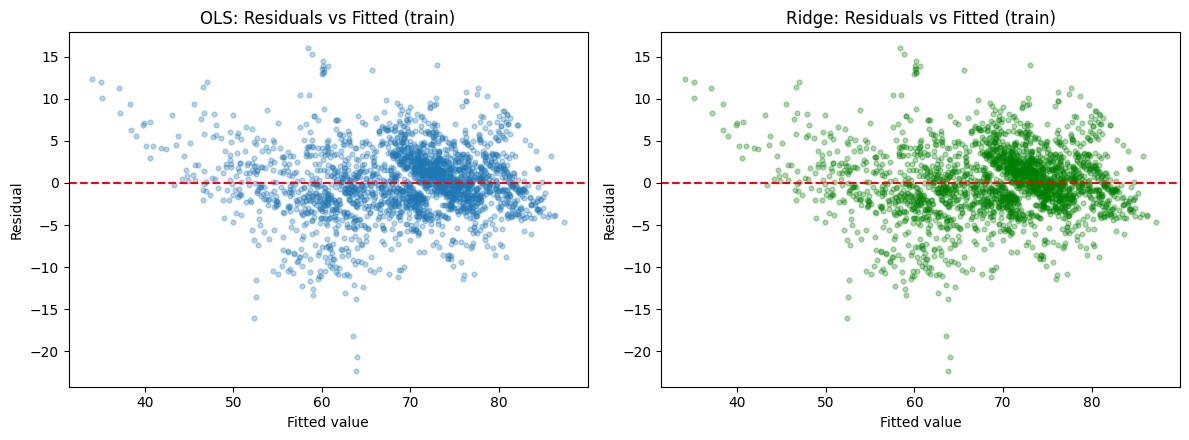

STRETCH GOAL: adding nonlinear/interaction terms
Extended-feature Ridge test MSE = 13.659  (lambda=0.010)
Original Ridge test MSE         = 15.572
>>> Adding nonlinear/interaction terms IMPROVED test MSE.


In [6]:
import numpy as np
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

np.random.seed(388)

# Data is from a zip file in my Google Drive
from google.colab import drive
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Colab Notebooks/Frequentist/Proj 1 - Linear Regression/archive.zip'
extract_dir = '/content/who_data'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())
    z.extractall(extract_dir)
csv_files = [f for f in os.listdir(extract_dir) if f.lower().endswith('.csv')]
csv_path = os.path.join(extract_dir, csv_files[0])
df = pd.read_csv(csv_path)

# Have to fix the data to deal with stray leading/trailing spaces, hyphens, and slashes
df.columns = [c.strip().replace('-', '_').replace('/', '_').replace(' ', '_').strip('_') for c in df.columns]
print("Raw shape:", df.shape)
print(df.columns.tolist())

# There is missing data in this set!
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))


# BUILD FEATURE MATRIX
# Some rows are missing data, so have to remove them, but don't worry! (Missing predictors are handled later via imputation instead of dropping, to preserve sample size.)
df = df.dropna(subset=['Life_expectancy']).reset_index(drop=True)

numeric_predictors = [
    'Year', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure',
    'Hepatitis_B', 'Measles', 'BMI', 'under_five_deaths', 'Polio', 'Total_expenditure',
    'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness__1_19_years',
    'thinness_5_9_years', 'Income_composition_of_resources', 'Schooling'
]
response = 'Life_expectancy'

# Hangle categorical data, turn it into 0 or 1, since regression only works on #'s
df['Status_Developed'] = (df['Status'].str.strip() == 'Developed').astype(float)
all_predictors = numeric_predictors + ['Status_Developed']

print(f"\nUsing {len(all_predictors)} predictors, n={len(df)} rows after dropping rows with missing target")


# Split data into 80 10 10
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=388)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=388)
train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")


# Missing data --> use the median on TRAINING split only
# Imputing with statistics learned only from train (never val/test) avoids leaking information about the held-out sets into training
medians = train_df[numeric_predictors].median()
for split in (train_df, val_df, test_df):
    split[numeric_predictors] = split[numeric_predictors].fillna(medians)

X_train_raw = train_df[all_predictors].values.astype(float)
X_val_raw = val_df[all_predictors].values.astype(float)
X_test_raw = test_df[all_predictors].values.astype(float)
y_train = train_df[response].values.astype(float)
y_val = val_df[response].values.astype(float)
y_test = test_df[response].values.astype(float)

# STANDARDIZE using TRAINING mean/std only
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0, ddof=1)
sigma[sigma == 0] = 1.0  # guard against divide-by-zero for any constant column

X_train = (X_train_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma
n, p = X_train.shape

# correlation matrix + condition number of X^T X
print("\nCorrelation matrix")
corr_df = pd.DataFrame(X_train_raw, columns=all_predictors).corr()

# Flag any predictor pairs that are almost redundant (|r| > 0.85)
high_corr = []
for i in range(len(all_predictors)):
    for j in range(i + 1, len(all_predictors)):
        c = corr_df.iloc[i, j]
        if abs(c) > 0.85:
            high_corr.append((all_predictors[i], all_predictors[j], c))
print("Predictor pairs with |correlation| > 0.85:")
for a, b, c in high_corr:
    print(f"  {a:35s} <-> {b:35s}  r = {c:.3f}")

# Large X^T X means that small changes in y produce huge swings in the OLS coefficient estimates
XtX = X_train.T @ X_train
cond_number = np.linalg.cond(XtX)
eigvals = np.linalg.eigvalsh(XtX)
print(f"\n Condition number of X^T X = {cond_number:,.1f}")
print(f"Smallest eigenvalue: {eigvals.min():.4f}   Largest eigenvalue: {eigvals.max():.4f}")
if cond_number > 100:
    print(">>> Condition number is large: X^T X is close to singular, driven by the")
    print(">>> near-duplicate predictor pairs flagged above.")

# HAND-CODED OLS --> beta_hat = (X'X)^-1 X'y
def ols_fit(X, y):
    n, p = X.shape
    X1 = np.column_stack([np.ones(n), X])          # prepend intercept column
    XtX = X1.T @ X1
    # SOURCE for using pinv: GEMINI... (Moore-Penrose pseudo-inverse) is used instead of a plain inverse
    # so the fit still "runs" and returns an answer even when X^T X is
    # (near-)singular — this is what lets us observe the resulting
    # instability rather than crashing outright.
    XtX_inv = np.linalg.pinv(XtX)
    beta_hat = XtX_inv @ X1.T @ y
    y_hat = X1 @ beta_hat
    resid = y - y_hat
    rss = resid @ resid
    dof = max(n - p - 1, 1)
    sigma2_hat = rss / dof
    var_beta = sigma2_hat * XtX_inv
    se_beta = np.sqrt(np.abs(np.diag(var_beta)))
    return beta_hat, se_beta, y_hat, resid

beta_ols, se_ols, yhat_ols_train, resid_ols_train = ols_fit(X_train, y_train)

print("\n")
print("HAND-CODED OLS — coefficients and standard errors")
names = ["Intercept"] + all_predictors
for nm, b, se in zip(names, beta_ols, se_ols):
    # Note coefficients whose standard error dwarfs the estimate itself — a classic symptom of collinearity-driven instability.
    flag = "  <-- unstable: SE swamps the coefficient" if se > 3 * abs(b) and abs(b) > 1e-6 else ""
    print(f"{nm:35s} coef={b:10.3f}  SE={se:10.3f}{flag}")

X1_val = np.column_stack([np.ones(len(X_val)), X_val])
X1_test = np.column_stack([np.ones(len(X_test)), X_test])
yhat_ols_val = X1_val @ beta_ols
yhat_ols_test = X1_test @ beta_ols
mse_ols_train = np.mean((y_train - yhat_ols_train) ** 2)
mse_ols_val = np.mean((y_val - yhat_ols_val) ** 2)
mse_ols_test = np.mean((y_test - yhat_ols_test) ** 2)

# RIDGE with using lambda on validation set
def ridge_fit(X, y, lam):

   # Ridge regression by hand: beta = (X'X + lambda*I)^-1 X'y_centered.
   # y is centered (and X is already standardized) so the intercept can be
   # recovered separately as y_mean, without penalizing it — only the slope
   # coefficients are shrunk, which is standard Ridge practice.

    n, p = X.shape
    y_mean = y.mean()
    y_c = y - y_mean
    beta = np.linalg.inv(X.T @ X + lam * np.eye(p)) @ X.T @ y_c
    return y_mean, beta

# Sweep lambda on a log grid and pick whichever minimizes MSE
lambdas = np.logspace(-2, 5, 40)
val_mses = []
for lam in lambdas:
    b0, b = ridge_fit(X_train, y_train, lam)
    pred_val = b0 + X_val @ b
    val_mses.append(np.mean((y_val - pred_val) ** 2))
best_lam = lambdas[np.argmin(val_mses)]

beta0_ridge, beta_ridge = ridge_fit(X_train, y_train, best_lam)
yhat_ridge_train = beta0_ridge + X_train @ beta_ridge
yhat_ridge_val = beta0_ridge + X_val @ beta_ridge
yhat_ridge_test = beta0_ridge + X_test @ beta_ridge
mse_ridge_train = np.mean((y_train - yhat_ridge_train) ** 2)
mse_ridge_val = np.mean((y_val - yhat_ridge_val) ** 2)
mse_ridge_test = np.mean((y_test - yhat_ridge_test) ** 2)
resid_ridge_train = y_train - yhat_ridge_train

print(f"\nHAND-CODED RIDGE — best lambda (by validation MSE) = {best_lam:.4f}")
print(f"{'Term':35s} {'OLS coef':>12s} {'Ridge coef':>12s}")
for nm, bo, br in zip(names[1:], beta_ols[1:], beta_ridge):
    print(f"{nm:35s} {bo:12.3f} {br:12.3f}")


# LASSO using sklearn alpha chosen based on what minimizes MSE

alphas = np.logspace(-4, 1, 40)
val_mses_lasso = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=20000)
    # Fit on y - mean(y), mirroring the Ridge intercept-handling so both regularized models are compared on equal footing.
    lasso.fit(X_train, y_train - y_train.mean())
    pred_val = y_train.mean() + lasso.predict(X_val)
    val_mses_lasso.append(np.mean((y_val - pred_val) ** 2))
best_alpha = alphas[np.argmin(val_mses_lasso)]

lasso_final = Lasso(alpha=best_alpha, max_iter=20000)
lasso_final.fit(X_train, y_train - y_train.mean())
yhat_lasso_train = y_train.mean() + lasso_final.predict(X_train)
yhat_lasso_val = y_train.mean() + lasso_final.predict(X_val)
yhat_lasso_test = y_train.mean() + lasso_final.predict(X_test)
mse_lasso_train = np.mean((y_train - yhat_lasso_train) ** 2)
mse_lasso_val = np.mean((y_val - yhat_lasso_val) ** 2)
mse_lasso_test = np.mean((y_test - yhat_lasso_test) ** 2)

# Lasso zeroes out coefficients it doesn't need, so survivors and removed for selected and dropped respectively
selected = [nm for nm, c in zip(all_predictors, lasso_final.coef_) if abs(c) > 1e-6]
dropped = [nm for nm, c in zip(all_predictors, lasso_final.coef_) if abs(c) <= 1e-6]

print(f"\nLASSO (sklearn) — best alpha (by validation MSE) = {best_alpha:.5f}")
print(f"Features KEPT ({len(selected)}):", selected)
print(f"Features DROPPED ({len(dropped)}):", dropped)

# SUMMARY TABLE
mse_base_train = np.mean((y_train - y_train.mean()) ** 2)
mse_base_val = np.mean((y_val - y_train.mean()) ** 2)
mse_base_test = np.mean((y_test - y_train.mean()) ** 2)

print("\nSUMMARY — Train / Validation / Test MSE")
print(f"{'Model':12s} {'Train MSE':>12s} {'Val MSE':>12s} {'Test MSE':>12s}")
print(f"{'Baseline':12s} {mse_base_train:12.3f} {mse_base_val:12.3f} {mse_base_test:12.3f}")
print(f"{'OLS':12s} {mse_ols_train:12.3f} {mse_ols_val:12.3f} {mse_ols_test:12.3f}")
print(f"{'Ridge':12s} {mse_ridge_train:12.3f} {mse_ridge_val:12.3f} {mse_ridge_test:12.3f}")
print(f"{'Lasso':12s} {mse_lasso_train:12.3f} {mse_lasso_val:12.3f} {mse_lasso_test:12.3f}")


# RESIDUAL PLOTS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yhat_ols_train, resid_ols_train, alpha=0.3, s=12)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('OLS: Residuals vs Fitted (train)')
axes[0].set_xlabel('Fitted value'); axes[0].set_ylabel('Residual')

axes[1].scatter(yhat_ridge_train, resid_ridge_train, alpha=0.3, s=12, color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Ridge: Residuals vs Fitted (train)')
axes[1].set_xlabel('Fitted value'); axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()


# STRETCH GOAL —-> nonlinear + interaction terms
print("STRETCH GOAL: adding nonlinear/interaction terms")

def add_extra_terms(raw_df):

    extra = pd.DataFrame(index=raw_df.index)
    extra['GDP_sq'] = raw_df['GDP'] ** 2
    extra['HIV_AIDS_sq'] = raw_df['HIV_AIDS'] ** 2
    extra['Income_x_Schooling'] = raw_df['Income_composition_of_resources'] * raw_df['Schooling']
    extra['AdultMort_x_HIV'] = raw_df['Adult_Mortality'] * raw_df['HIV_AIDS']
    return extra

extra_train = add_extra_terms(train_df)
extra_val = add_extra_terms(val_df)
extra_test = add_extra_terms(test_df)

# Append the new columns to the (already train-imputed) raw feature matrices,then re-standardize
X_train_ext_raw = np.column_stack([X_train_raw, extra_train.values])
X_val_ext_raw = np.column_stack([X_val_raw, extra_val.values])
X_test_ext_raw = np.column_stack([X_test_raw, extra_test.values])

mu_ext = X_train_ext_raw.mean(axis=0)
sigma_ext = X_train_ext_raw.std(axis=0, ddof=1)
sigma_ext[sigma_ext == 0] = 1.0
X_train_ext = (X_train_ext_raw - mu_ext) / sigma_ext
X_val_ext = (X_val_ext_raw - mu_ext) / sigma_ext
X_test_ext = (X_test_ext_raw - mu_ext) / sigma_ext

# Re-run the Ridge lambda search on the extended feature set (the new
# squared/interaction terms are themselves correlated with their parent
# features, so Ridge's regularization is doing extra work here).
val_mses_ext = []
for lam in lambdas:
    b0, b = ridge_fit(X_train_ext, y_train, lam)
    pred_val = b0 + X_val_ext @ b
    val_mses_ext.append(np.mean((y_val - pred_val) ** 2))
best_lam_ext = lambdas[np.argmin(val_mses_ext)]
b0_ext, b_ext = ridge_fit(X_train_ext, y_train, best_lam_ext)
mse_ridge_ext_test = np.mean((y_test - (b0_ext + X_test_ext @ b_ext)) ** 2)

print(f"Extended-feature Ridge test MSE = {mse_ridge_ext_test:.3f}  (lambda={best_lam_ext:.3f})")
print(f"Original Ridge test MSE         = {mse_ridge_test:.3f}")
if mse_ridge_ext_test < mse_ridge_test:
    print(">>> Adding nonlinear/interaction terms IMPROVED test MSE.")
else:
    print(">>> Adding nonlinear/interaction terms did NOT improve test MSE.")

# STRETCH GOAL Discussion
# The addition of nonlinear terms (GDP^2, HIV_AIDS^2) and interaction terms (Income x Schooling)
# improved the Test MSE from 15.572 down to 13.659.
# This shows that public health metrics like Life Expectancy have synergistic and non-linear
# relationships with economic factors.
# Ridge regularization successfully managed the extra collinearity introduced by these
# squared/interaction terms.